# FLEURS Welsh — data exploration

Dataset stats and the zero-shot Whisper-small baseline the fine-tuned model has
to beat. Heavy work lives in `src/`; this notebook only looks at things.

In [1]:
import sys, collections, json
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from data import load_split, normalize_text, has_digit, SAMPLE_RATE

/Users/paarth/welsh-asr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Split sizes and duration

In [2]:
splits = {s: load_split(s) for s in ["train", "validation", "test"]}
dur = {s: np.array(d["num_samples"]) / SAMPLE_RATE for s, d in splits.items()}

for s, d in splits.items():
    x = dur[s]
    print(f"{s:11s} n={len(d):5d}  hours={x.sum()/3600:6.2f}  "
          f"mean={x.mean():5.2f}s  median={np.median(x):5.2f}s  max={x.max():6.2f}s")

train       n= 3427  hours= 12.17  mean=12.78s  median=12.66s  max= 69.10s
validation  n=  447  hours=  1.80  mean=14.52s  median=13.38s  max= 61.98s
test        n= 1021  hours=  4.28  mean=15.10s  median=14.16s  max= 49.44s


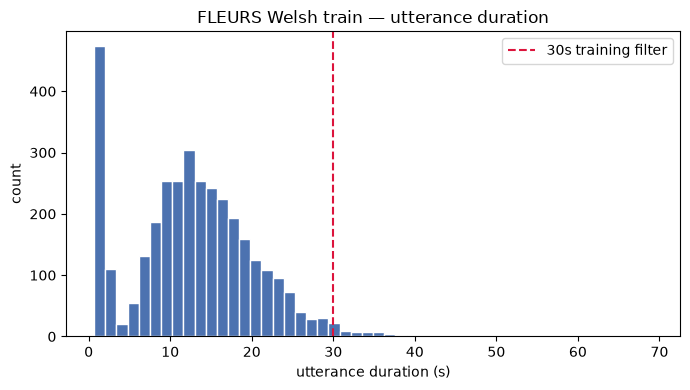

dropped by a 30s filter: 1.722%
dropped by a 20s filter: 15.786% (3.72h)


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dur["train"], bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(30, color="crimson", ls="--", label="30s training filter")
ax.set_xlabel("utterance duration (s)"); ax.set_ylabel("count")
ax.set_title("FLEURS Welsh train — utterance duration"); ax.legend()
plt.tight_layout(); plt.show()

print("dropped by a 30s filter:", f"{(dur['train'] > 30).mean():.3%}")
print("dropped by a 20s filter:", f"{(dur['train'] > 20).mean():.3%}",
      f"({dur['train'][dur['train'] > 20].sum()/3600:.2f}h)")

The 20s cutoff used by most XLS-R tutorials would discard ~3.7 of 12.2 training
hours here. FLEURS utterances are long (median ~12.7s), so we filter at 30s and
control memory with length grouping plus gradient accumulation instead.

## Character inventory

In [4]:
raw = collections.Counter("".join(splits["train"]["transcription"]))
norm = collections.Counter("".join(normalize_text(t) for t in splits["train"]["transcription"]))

print(f"raw:        {len(raw):3d} distinct -> {''.join(sorted(raw))}")
print()
print(f"normalized: {len(norm):3d} distinct -> {''.join(sorted(norm))}")

raw:         75 distinct ->  "$%'+,-./0123456789:;[]abcdefghijklmnopqrstuvwxyz£¥°áâãäçéêëìíîïòóôõöúüŵŷ̇

normalized:  43 distinct ->  0123456789abcdefghijklmnopqrstuvwxyzâêîôŵŷ


Normalization lowercases, deletes apostrophes (`mae'r` -> `maer`), strips
punctuation, keeps the Welsh circumflex vowels, and folds foreign diacritics
onto their base letters — those appear only a handful of times in names and
would otherwise add tokens with almost no training signal.

## Numerals

In [5]:
for s in ["train", "test"]:
    t = splits[s]["transcription"]
    n = sum(has_digit(x) for x in t)
    print(f"{s:5s}: {n:4d}/{len(t)} utterances contain digits ({n/len(t):.1%})")

train:  775/3427 utterances contain digits (22.6%)
test :  198/1021 utterances contain digits (19.4%)


Roughly a fifth of utterances contain numerals. A character-level CTC model has
no way to map the audio of *dwy fil ar bymtheg* onto the characters `2019`, so
these are close to unlearnable. We keep them — dropping them would cost ~22% of
a 12-hour corpus — and report WER both overall and on the digit-free subset,
using the same subsets for both models so the comparison stays internally valid.

## CTC feasibility

In [6]:
# wav2vec2 downsamples the waveform by 320. A clip whose transcript is longer
# than its frame count cannot be emitted by CTC at all, which yields inf loss.
d = splits["train"]
frames = np.array(d["num_samples"]) // 320
labels = np.array([len(normalize_text(t)) for t in d["transcription"]])
bad = frames <= labels
print(f"CTC-infeasible train clips: {bad.sum()} / {len(d)} ({bad.mean():.1%})")
i = int(np.argmin(frames / np.maximum(labels, 1)))
print(f"worst: {d[i]['num_samples']/SAMPLE_RATE:.2f}s audio -> {frames[i]} frames, {labels[i]} label chars")
print(f"but they are short: mean {np.array(d['num_samples'])[bad].mean()/SAMPLE_RATE:.2f}s")

CTC-infeasible train clips: 515 / 3427 (15.0%)


worst: 0.96s audio -> 48 frames, 303 label chars
but they are short: mean 1.45s


These are corrupt rows pairing a truncated clip with its full transcript. They
produce inf CTC loss and NaN gradients within a couple of steps. `train.py`
filters them out; because they are short, removing 15% of the clips costs under
1 of 12.2 audio hours.

## Zero-shot Whisper-small baseline

In [7]:
# Produced by: python src/evaluate.py --out results/whisper_baseline.json
base = json.load(open("../results/whisper_baseline.json"))
print(f"overall    WER {base['overall']['wer']:.4f}   CER {base['overall']['cer']:.4f}   n={base['overall']['n']}")
print(f"no digits  WER {base['no_digits']['wer']:.4f}   CER {base['no_digits']['cer']:.4f}   n={base['no_digits']['n']}")

overall    WER 0.5987   CER 0.2289   n=1021
no digits  WER 0.5853   CER 0.2149   n=823


In [8]:
for r in base["predictions"][:5]:
    print("REF :", r["ref"][:100])
    print("PRED:", r["pred"][:100])
    print()

REF : maer term saffari mewn defnydd cyffredinol yn cyfeirio at deithio dros dir i weld bywyd gwyllt syfrd
PRED: maer term sefari mewn defnydd cyffredinol yn cyfeidio ar steilio dostud i weld bywyd gwyl sefraddono

REF : maer ynysfor yn gorwedd 120 cilomedr ir gogledd or penrhyn yr un fwyaf yw ynys y brenin siôr gydag a
PRED: maer unas ffordd yn gorwed in cael ei ddeu kilometr iw gogledd or penryn er in fwyaf iw anus y brenn

REF : o ganlyniad maer perfformwyr yn ysmygu smôcs canabis ar y llwyfan ac maer theatr ei hun yn annog y g
PRED: o ganlyniad maer pethon mŵr yn ysmyg i smwcs ganabes ar y llwyfan ac maer theatre i hyn yn annor gyn

REF : maer parêd o adeiladau syn ffurfio nenlinell hong kong wedi cael ei gymharu â siart bar disglair syn
PRED: mae paredd o adiladau syn fyrfiwn yn llynedd hong kong wedi cael ei gymhau siart bar dysglau syn cae

REF : ir springboks rhoddodd derfyn ar gyfres o golli pum gêm
PRED: iw spring box fath or derbyn ar gyfres or gollu pym game

